# Evaluacion comparativa de modelos ML

Esta libreta carga los tres modelos entrenados (RF, SVM, XGBoost) y los evalúa sobre un conjunto de test independiente.

**Flujo:**
1. Preparar el conjunto de test en `src/classifier/data/test/` (mismo formato que training).
2. Cargar los tres `ModelBundle` desde sus carpetas de artefactos.
3. Extraer features y aplicar los tres modelos al manifest de test.
4. Comparar métricas y matrices de confusión.
5. Comparar distribuciones de probabilidad por clase.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from classifier.code.inference import (
    load_model_bundle,
    compare_models,
    compute_comparison_metrics,
    predict_manifest,
)
from classifier.code.prepare_dataset import convert_raw_manifest_to_training_dataset

print("Entorno cargado correctamente")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

Entorno cargado correctamente
PROJECT_ROOT: C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM


In [2]:
import sys
import sklearn
import xgboost as xgb

print("RUTA DEL PYTHON DE LA LIBRETA:")
print(sys.executable)
print("\nVERSIONES:")
print(f"Scikit-Learn: {sklearn.__version__}")
print(f"XGBoost: {xgb.__version__}")

RUTA DEL PYTHON DE LA LIBRETA:
d:\anaconda3\envs\exoplanet-tfm\python.exe

VERSIONES:
Scikit-Learn: 1.9.0
XGBoost: 3.2.0


In [3]:
# ====================== CONFIGURACION ======================

# Carpetas de artefactos de cada modelo
RF_ARTIFACTS  = PROJECT_ROOT / "src/classifier/artifacts/rf_final"
SVM_ARTIFACTS = PROJECT_ROOT / "src/classifier/artifacts/svm_final"
XGB_ARTIFACTS = PROJECT_ROOT / "src/classifier/artifacts/xgb_final"

# Rutas del dataset de test
TEST_RAW_DIR       = PROJECT_ROOT / "src/classifier/data/test/raw"
TEST_PROCESSED_DIR = PROJECT_ROOT / "src/classifier/data/test/processed"
TEST_RAW_MANIFEST  = PROJECT_ROOT / "src/classifier/data/test/raw_manifest_test.csv"
TEST_MANIFEST      = PROJECT_ROOT / "src/classifier/data/test/manifest_test.csv"

FLUX_COLUMN = "detrended_flux"
TIME_COLUMN = "time_jd"

TEST_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print("Rutas configuradas:")
print(f"  RF:  {RF_ARTIFACTS}  | exists={RF_ARTIFACTS.exists()}")
print(f"  SVM: {SVM_ARTIFACTS} | exists={SVM_ARTIFACTS.exists()}")
print(f"  XGB: {XGB_ARTIFACTS} | exists={XGB_ARTIFACTS.exists()}")
print(f"  Test manifest esperado: {TEST_MANIFEST}")

Rutas configuradas:
  RF:  C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\src\classifier\artifacts\rf_final  | exists=True
  SVM: C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\src\classifier\artifacts\svm_final | exists=True
  XGB: C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\src\classifier\artifacts\xgb_final | exists=True
  Test manifest esperado: C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\src\classifier\data\test\manifest_test.csv


## 1. Preparar conjunto de test

Si ya tienes un `raw_manifest_test.csv` en `src/classifier/data/test/`, esta celda lo convierte a `manifest_test.csv` con los CSV normalizados en `processed/`.

El formato de `raw_manifest_test.csv` es el mismo que `raw_manifest_generated.csv`:
```
sample_id, label, source_type, raw_path, [format_hint], [flux_column], [time_column]
```
- `label`: 1 = tránsito de calidad, 0 = negativa / mala calidad
- Si no tienes etiquetas todavía, pon `label = -1` y omite las métricas.

In [4]:
if not TEST_RAW_MANIFEST.exists():
    print(f"[AVISO] No se encontro raw_manifest_test.csv en {TEST_RAW_MANIFEST.parent}")
    print("Crea ese archivo con las rutas a tus curvas de test y vuelve a ejecutar esta celda.")
else:
    print(f"Convirtiendo raw manifest de test -> processed + manifest_test.csv ...")
    test_manifest_df = convert_raw_manifest_to_training_dataset(
        raw_manifest_path=TEST_RAW_MANIFEST,
        processed_dir=TEST_PROCESSED_DIR,
        output_manifest_path=TEST_MANIFEST,
    )
    print(f"Listo: {len(test_manifest_df)} curvas procesadas")
    if "label" in test_manifest_df.columns:
        print(test_manifest_df["label"].value_counts().sort_index())

Convirtiendo raw manifest de test -> processed + manifest_test.csv ...
Listo: 2487 curvas procesadas
label
0    2000
1     487
Name: count, dtype: int64


## 2. Cargar los tres modelos

In [5]:
bundle_rf  = load_model_bundle(RF_ARTIFACTS, name="rf")
bundle_svm = load_model_bundle(SVM_ARTIFACTS, name="svm")
bundle_xgb = load_model_bundle(XGB_ARTIFACTS, name="xgb")

bundles = [bundle_rf, bundle_svm, bundle_xgb]

for b in bundles:
    print(f"[{b.name}] threshold={b.decision_threshold:.4f} ({b.threshold_strategy}) | features={len(b.feature_columns)}")

[rf] threshold=0.5000 (default_0.5) | features=13
[svm] threshold=0.5000 (default_0.5) | features=13
[xgb] threshold=0.5180 (youden) | features=13


## 3. Inferencia comparativa sobre el manifest de test

In [6]:
if not TEST_MANIFEST.exists():
    raise FileNotFoundError(f"Manifest de test no encontrado: {TEST_MANIFEST}\nEjecuta primero la celda de preparacion.")

BATCH_SIZE = 250
CHECKPOINT_PATH = PROJECT_ROOT / "src/classifier/data/test/comparison_results_partial.csv"

manifest_df = pd.read_csv(TEST_MANIFEST)
n_total = len(manifest_df)

partials: list[pd.DataFrame] = []
processed_ids: set[str] = set()

if CHECKPOINT_PATH.exists():
    prev = pd.read_csv(CHECKPOINT_PATH)
    if "sample_id" in prev.columns and len(prev) > 0:
        prev = prev.drop_duplicates(subset="sample_id", keep="last")
        partials.append(prev)
        processed_ids = set(prev["sample_id"].astype(str).tolist())
        print(f"Reanudando desde checkpoint: {len(processed_ids)} curvas ya procesadas")

pending_df = manifest_df[~manifest_df["sample_id"].astype(str).isin(processed_ids)].reset_index(drop=True)
print(f"Curvas totales: {n_total} | pendientes: {len(pending_df)}")

if len(pending_df) > 0:
    n_batches = int(np.ceil(len(pending_df) / BATCH_SIZE))
    for i in range(n_batches):
        lo = i * BATCH_SIZE
        hi = min((i + 1) * BATCH_SIZE, len(pending_df))
        batch = pending_df.iloc[lo:hi].copy()

        tmp_manifest = TEST_MANIFEST.parent / f".tmp_manifest_batch_{i:03d}.csv"
        batch.to_csv(tmp_manifest, index=False)

        try:
            batch_df = compare_models(
                bundles=bundles,
                manifest_path=tmp_manifest,
                flux_column=FLUX_COLUMN,
                time_column=TIME_COLUMN,
                true_label_col="label",
            )
        finally:
            if tmp_manifest.exists():
                tmp_manifest.unlink()

        partials.append(batch_df)

        checkpoint_df = pd.concat(partials, ignore_index=True)
        checkpoint_df = checkpoint_df.drop_duplicates(subset="sample_id", keep="last")
        checkpoint_df.to_csv(CHECKPOINT_PATH, index=False)

        done = len(checkpoint_df)
        print(f"Lote {i + 1}/{n_batches} completado | acumulado: {done}/{n_total}")

comparison_df = pd.concat(partials, ignore_index=True)
comparison_df = comparison_df.drop_duplicates(subset="sample_id", keep="last").reset_index(drop=True)

print(f"Curvas evaluadas: {len(comparison_df)}")
comparison_df.head(10)

Curvas totales: 2487 | pendientes: 2487
Lote 1/10 completado | acumulado: 250/2487
Lote 2/10 completado | acumulado: 500/2487
Lote 3/10 completado | acumulado: 750/2487
Lote 4/10 completado | acumulado: 1000/2487
Lote 5/10 completado | acumulado: 1250/2487
Lote 6/10 completado | acumulado: 1500/2487
Lote 7/10 completado | acumulado: 1750/2487
Lote 8/10 completado | acumulado: 2000/2487
Lote 9/10 completado | acumulado: 2250/2487
Lote 10/10 completado | acumulado: 2487/2487
Curvas evaluadas: 2487


,sample_id,curve_path,source_type,label_true,prob_pos_rf,label_pred_rf,prob_pos_svm,label_pred_svm,prob_pos_xgb,label_pred_xgb
0,neg_baseline_0_00006,C:\Users\Daniel\Desktop\En curso\Máster Astrof...,neg_baseline,0,0.007833,0,0.028061,0,0.003013,0
1,neg_baseline_0_00012,C:\Users\Daniel\Desktop\En curso\Máster Astrof...,neg_baseline,0,0.051238,0,0.059825,0,0.003322,0
2,neg_baseline_0_00015,C:\Users\Daniel\Desktop\En curso\Máster Astrof...,neg_baseline,0,0.008000,0,0.005394,0,0.001665,0
3,neg_baseline_0_00018,C:\Users\Daniel\Desktop\En curso\Máster Astrof...,neg_baseline,0,0.002000,0,0.036656,0,0.003503,0
4,neg_baseline_0_00023,C:\Users\Daniel\Desktop\En curso\Máster Astrof...,neg_baseline,0,0.000000,0,0.028560,0,0.001218,0
5,neg_baseline_0_00026,C:\Users\Daniel\Desktop\En curso\Máster Astrof...,neg_baseline,0,0.000000,0,0.003503,0,0.001889,0
6,neg_baseline_0_00028,C:\Users\Daniel\Desktop\En curso\Máster Astrof...,neg_baseline,0,0.043024,0,0.006710,0,0.013543,0
7,neg_baseline_0_00030,C:\Users\Daniel\Desktop\En curso\Máster Astrof...,neg_baseline,0,0.000000,0,0.030349,0,0.000708,0
8,neg_baseline_0_00031,C:\Users\Daniel\Desktop\En curso\Máster Astrof...,neg_baseline,0,0.000000,0,0.011974,0,0.008370,0
9,neg_baseline_0_00034,C:\Users\Daniel\Desktop\En curso\Máster Astrof...,neg_baseline,0,0.007667,0,0.010360,0,0.001322,0


## 4. Tabla resumen de métricas por modelo

In [7]:
if "label_true" not in comparison_df.columns:
    print("No hay etiquetas verdaderas (label_true). Se omite el calculo de metricas.")
else:
    metrics_df = compute_comparison_metrics(comparison_df, bundles)
    print("\n=== TABLA COMPARATIVA DE METRICAS ===")
    display(metrics_df.set_index("model"))


=== TABLA COMPARATIVA DE METRICAS ===


,n_evaluated,n_errors,threshold,accuracy,precision,recall,f1
model,,,,,,,
rf,2487,0,0.500000,0.9558,0.8301,0.9733,0.8960
svm,2487,0,0.500000,0.9184,0.7375,0.9055,0.8129
xgb,2487,0,0.517975,0.9513,0.8389,0.9302,0.8822


## 5. Matrices de confusión

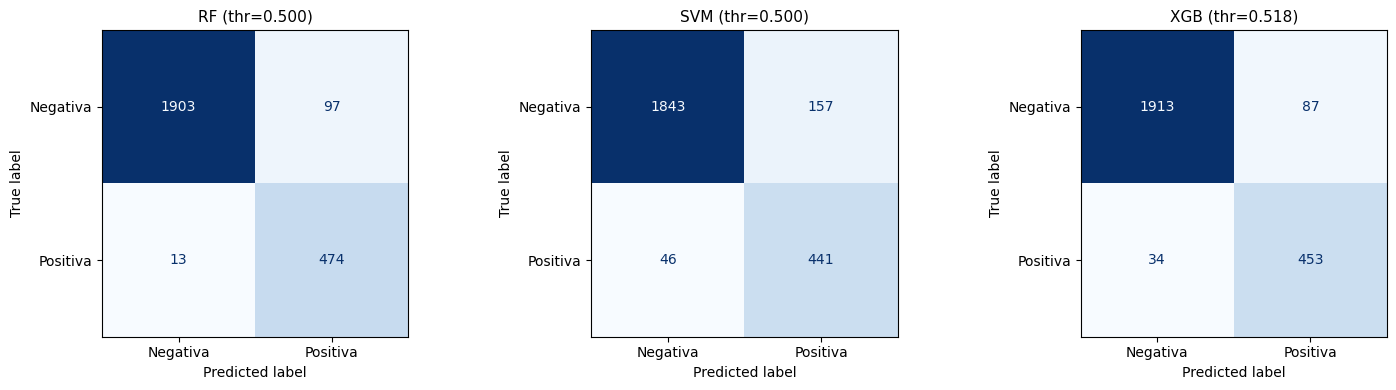

In [8]:
if "label_true" not in comparison_df.columns:
    print("Sin etiquetas verdaderas; se omite matriz de confusion.")
else:
    from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

    y_true = comparison_df["label_true"].to_numpy(dtype=int)
    fig, axes = plt.subplots(1, len(bundles), figsize=(5 * len(bundles), 4), squeeze=False)

    for ax, bundle in zip(axes[0], bundles):
        col = f"label_pred_{bundle.name}"
        valid = comparison_df[col] >= 0
        y_pred = comparison_df.loc[valid, col].to_numpy(dtype=int)
        cm = confusion_matrix(y_true[valid.to_numpy()], y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativa", "Positiva"])
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{bundle.name.upper()} (thr={bundle.decision_threshold:.3f})", fontsize=11)

    plt.tight_layout()
    plt.show()

## 6. Distribución de probabilidades por clase

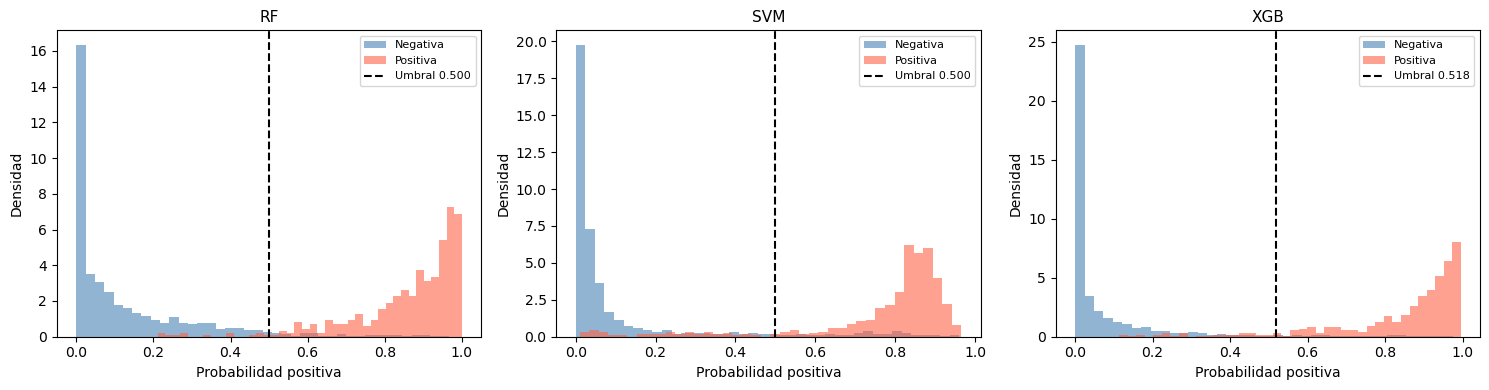

In [9]:
if "label_true" not in comparison_df.columns:
    print("Sin etiquetas verdaderas; se omite distribucion de probabilidades.")
else:
    fig, axes = plt.subplots(1, len(bundles), figsize=(5 * len(bundles), 4), squeeze=False)

    for ax, bundle in zip(axes[0], bundles):
        col = f"prob_pos_{bundle.name}"
        if col not in comparison_df.columns:
            continue
        for label_val, color, label_name in [(0, "steelblue", "Negativa"), (1, "tomato", "Positiva")]:
            mask = comparison_df["label_true"] == label_val
            probs = comparison_df.loc[mask, col].dropna()
            ax.hist(probs, bins=40, alpha=0.6, color=color, label=label_name, density=True)
        ax.axvline(bundle.decision_threshold, color="black", ls="--", lw=1.5, label=f"Umbral {bundle.decision_threshold:.3f}")
        ax.set_title(f"{bundle.name.upper()}", fontsize=11)
        ax.set_xlabel("Probabilidad positiva")
        ax.set_ylabel("Densidad")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## 7. Curvas ROC comparadas

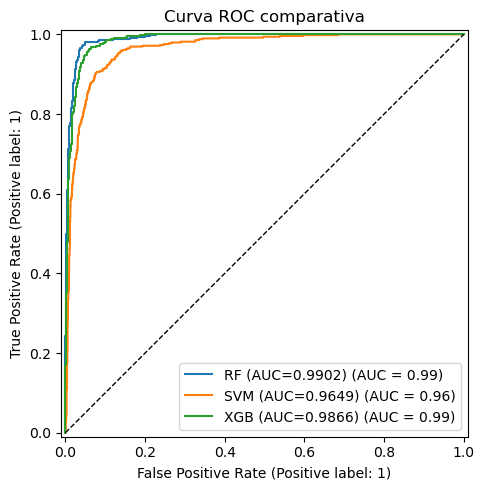

In [10]:
if "label_true" not in comparison_df.columns:
    print("Sin etiquetas verdaderas; se omite curva ROC.")
else:
    from sklearn.metrics import RocCurveDisplay, roc_auc_score

    fig, ax = plt.subplots(figsize=(6, 5))
    y_true = comparison_df["label_true"].to_numpy(dtype=int)

    colors = {"rf": "steelblue", "svm": "darkorange", "xgb": "forestgreen"}
    for bundle in bundles:
        col = f"prob_pos_{bundle.name}"
        if col not in comparison_df.columns:
            continue
        valid = comparison_df[col].notna()
        y_prob = comparison_df.loc[valid, col].to_numpy(dtype=float)
        y_t = y_true[valid.to_numpy()]
        auc = roc_auc_score(y_t, y_prob)
        RocCurveDisplay.from_predictions(
            y_t, y_prob,
            ax=ax,
            name=f"{bundle.name.upper()} (AUC={auc:.4f})",
        )

    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_title("Curva ROC comparativa", fontsize=12)
    plt.tight_layout()
    plt.show()

## 8. Casos de desacuerdo entre modelos

Filas donde los tres modelos no coinciden en la predicción (interesantes para inspección visual).

In [11]:
pred_cols = [f"label_pred_{b.name}" for b in bundles if f"label_pred_{b.name}" in comparison_df.columns]

disagreement = comparison_df[comparison_df[pred_cols].nunique(axis=1) > 1].copy()
print(f"Curvas con desacuerdo entre modelos: {len(disagreement)} / {len(comparison_df)}")
if len(disagreement) > 0:
    cols_show = ["sample_id", "source_type"] + (["label_true"] if "label_true" in comparison_df.columns else []) + pred_cols + [f"prob_pos_{b.name}" for b in bundles if f"prob_pos_{b.name}" in comparison_df.columns]
    display(disagreement[cols_show].head(30))

Curvas con desacuerdo entre modelos: 175 / 2487


,sample_id,source_type,label_true,label_pred_rf,label_pred_svm,label_pred_xgb,prob_pos_rf,prob_pos_svm,prob_pos_xgb
22,neg_baseline_0_00076,neg_baseline,0,0,0,1,0.385911,0.199185,0.662883
46,neg_baseline_0_00157,neg_baseline,0,0,1,0,0.454750,0.681615,0.307795
50,neg_baseline_0_00174,neg_baseline,0,1,0,1,0.522060,0.141379,0.520902
86,neg_baseline_0_00323,neg_baseline,0,0,1,1,0.407179,0.710165,0.586021
146,neg_baseline_0_00581,neg_baseline,0,0,0,1,0.398274,0.146043,0.674224
162,neg_baseline_0_00648,neg_baseline,0,0,1,0,0.347337,0.706741,0.105634
256,neg_baseline_0_00995,neg_baseline,0,0,0,1,0.386333,0.178405,0.673349
277,neg_baseline_0_01057,neg_baseline,0,0,0,1,0.430839,0.289677,0.636911
422,neg_baseline_0_01654,neg_baseline,0,0,0,1,0.475353,0.347025,0.553447
494,neg_baseline_0_01921,neg_baseline,0,1,0,1,0.656929,0.260235,0.753835


## 9. Visualizacion de curvas en desacuerdo

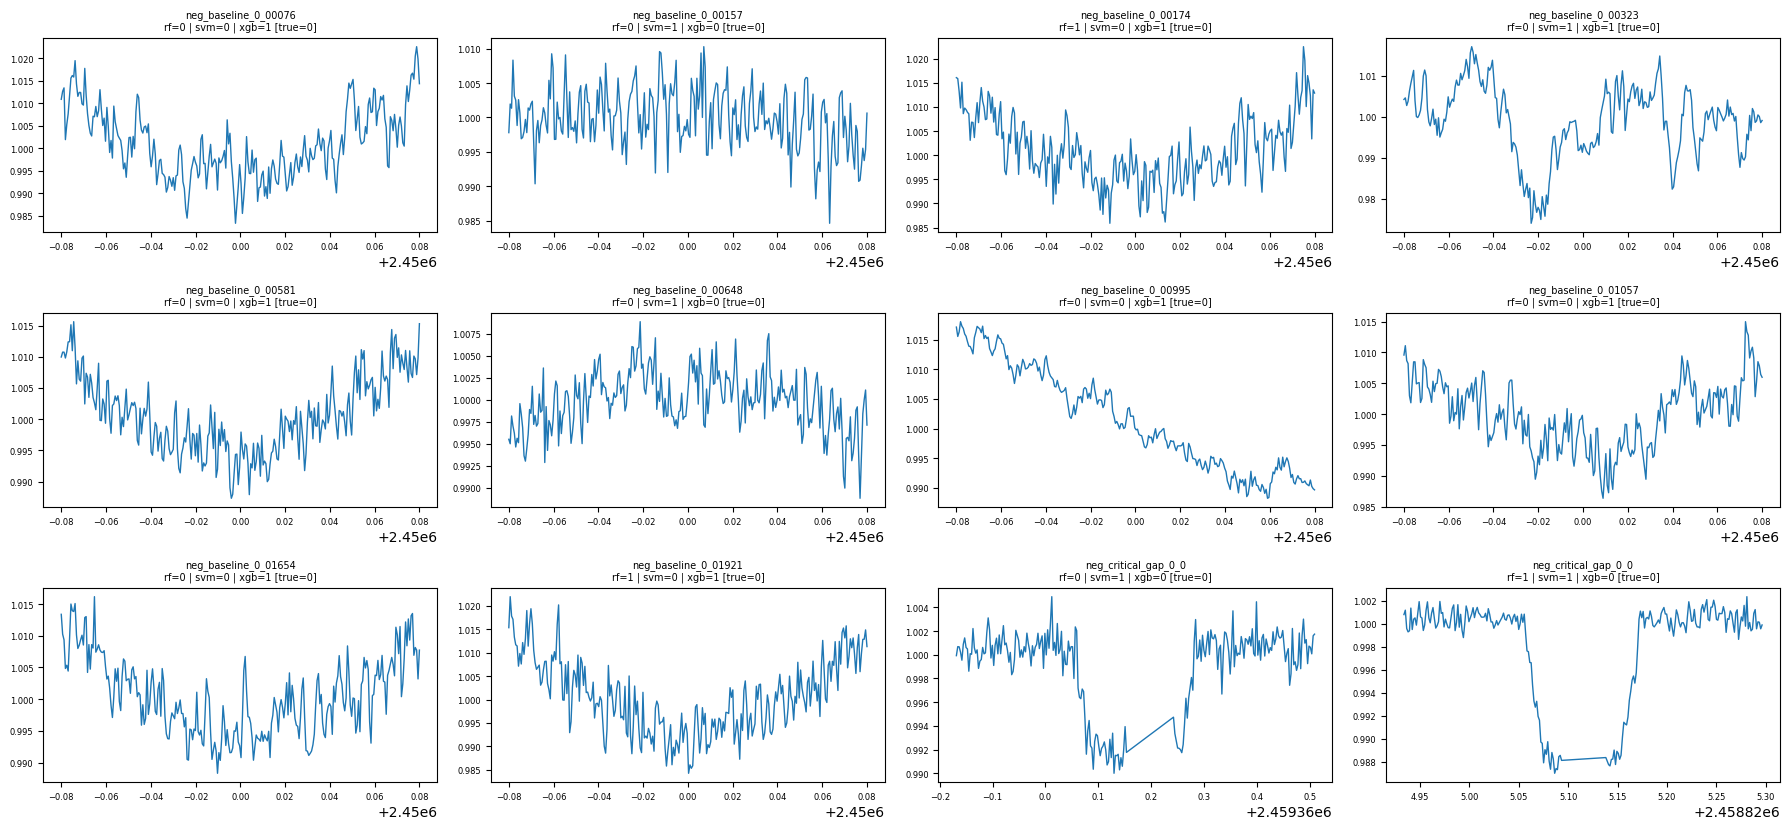

In [12]:
MAX_PLOT = 12
sample = disagreement.head(MAX_PLOT)

if len(sample) == 0:
    print("No hay curvas en desacuerdo para visualizar.")
else:
    ncols = 4
    nrows = int(np.ceil(len(sample) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 2.8 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for i, (_, row) in enumerate(sample.iterrows()):
        ax = axes_flat[i]
        try:
            cdf = pd.read_csv(row["curve_path"])
            x = np.asarray(cdf[TIME_COLUMN], dtype=float)
            y = np.asarray(cdf[FLUX_COLUMN], dtype=float)
            ax.plot(x, y, lw=1.0)
            preds = " | ".join(f"{b.name}={int(row[f'label_pred_{b.name}'])}" for b in bundles if f"label_pred_{b.name}" in row)
            true_lbl = f" [true={int(row['label_true'])}]" if "label_true" in row else ""
            ax.set_title(f"{row['sample_id'][:20]}\n{preds}{true_lbl}", fontsize=7)
            ax.tick_params(labelsize=6)
        except Exception as exc:
            ax.text(0.5, 0.5, str(exc), ha="center", va="center", fontsize=7)
            ax.set_axis_off()

    for j in range(len(sample), len(axes_flat)):
        axes_flat[j].set_axis_off()

    plt.tight_layout()
    plt.show()

## 10. Exportar resultados completos

In [13]:
OUT_COMPARISON = PROJECT_ROOT / "src/classifier/data/test/comparison_results.csv"
comparison_df.to_csv(OUT_COMPARISON, index=False)
print(f"Resultados guardados en: {OUT_COMPARISON}")

if "label_true" in comparison_df.columns:
    OUT_METRICS = PROJECT_ROOT / "src/classifier/data/test/comparison_metrics.csv"
    metrics_df.to_csv(OUT_METRICS, index=False)
    print(f"Métricas guardadas en: {OUT_METRICS}")

Resultados guardados en: C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\src\classifier\data\test\comparison_results.csv
Métricas guardadas en: C:\Users\Daniel\Desktop\En curso\Máster Astrofísica\TFM\src\classifier\data\test\comparison_metrics.csv
